In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# Cố định seed để chạy đi chạy lại ra cùng một kết quả.
# Khi báo cáo bài lab, các em luôn nên đặt seed.
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Đang dùng device:', device)

Đang dùng device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root='./data', train=True,  transform=transform, download=True)
test_dataset  = MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)}')
print(f'Số ảnh test : {len(test_dataset)}')
print(f'Kích thước 1 ảnh: {train_dataset[0][0].shape}  (channel x H x W)')

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.56MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]

Số ảnh train: 60000
Số ảnh test : 10000
Kích thước 1 ảnh: torch.Size([1, 28, 28])  (channel x H x W)


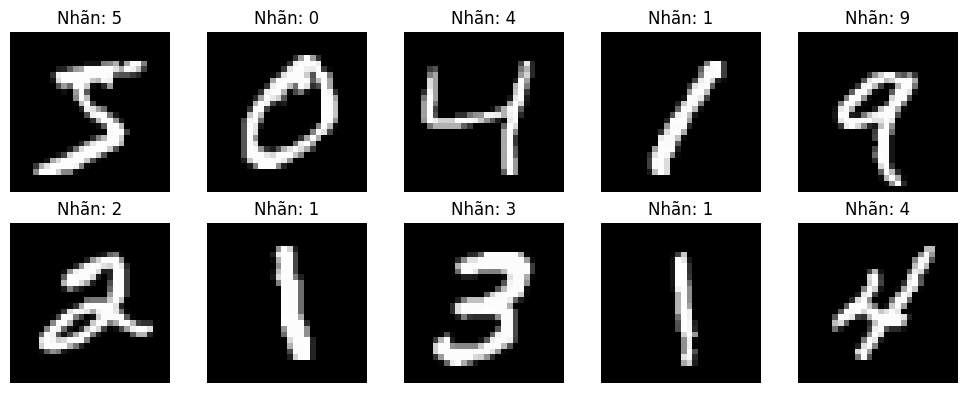

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # img có shape (1, 28, 28); .squeeze() bỏ chiều channel để vẽ.
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Nhãn: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
        # KHÔNG có Softmax ở đây — CrossEntropyLoss sẽ lo phần đó.

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)   # trả về logits, shape (batch, 10)
        return x

model = ANN().to(device)
print(model)

# Đếm số tham số để biết model nặng cỡ nào.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng số tham số: {n_params:,}')

ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Tổng số tham số: 101,770


In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def evaluate(model, loader):
    # Trả về (loss trung bình, accuracy) của model trên một loader bất kỳ.
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

num_epochs = 10
train_loss_history, train_acc_history = [], []
test_loss_history,  test_acc_history  = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Cộng dồn: nhân loss với batch_size để tính trung bình theo mẫu, không theo batch.
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%   '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch  1/10  train_loss=0.2585  train_acc=92.43%   test_loss=0.1324  test_acc=95.90%
Epoch  2/10  train_loss=0.1129  train_acc=96.64%   test_loss=0.1029  test_acc=96.94%
Epoch  3/10  train_loss=0.0785  train_acc=97.61%   test_loss=0.0976  test_acc=96.98%
Epoch  4/10  train_loss=0.0612  train_acc=98.03%   test_loss=0.0729  test_acc=97.74%
Epoch  5/10  train_loss=0.0461  train_acc=98.52%   test_loss=0.0762  test_acc=97.73%
Epoch  6/10  train_loss=0.0383  train_acc=98.75%   test_loss=0.0891  test_acc=97.34%
Epoch  7/10  train_loss=0.0313  train_acc=98.94%   test_loss=0.0900  test_acc=97.49%
Epoch  8/10  train_loss=0.0264  train_acc=99.11%   test_loss=0.0897  test_acc=97.65%
Epoch  9/10  train_loss=0.0230  train_acc=99.23%   test_loss=0.0790  test_acc=97.95%
Epoch 10/10  train_loss=0.0186  train_acc=99.40%   test_loss=0.0930  test_acc=97.64%


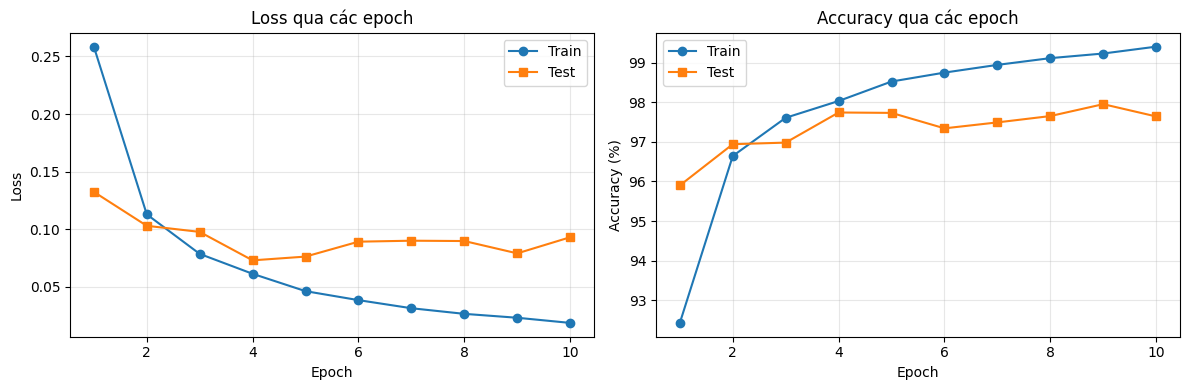

In [ ]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss_history, 'o-', label='Train')
axes[0].plot(epochs, test_loss_history,  's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss qua các epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in train_acc_history], 'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history],  's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy qua các epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

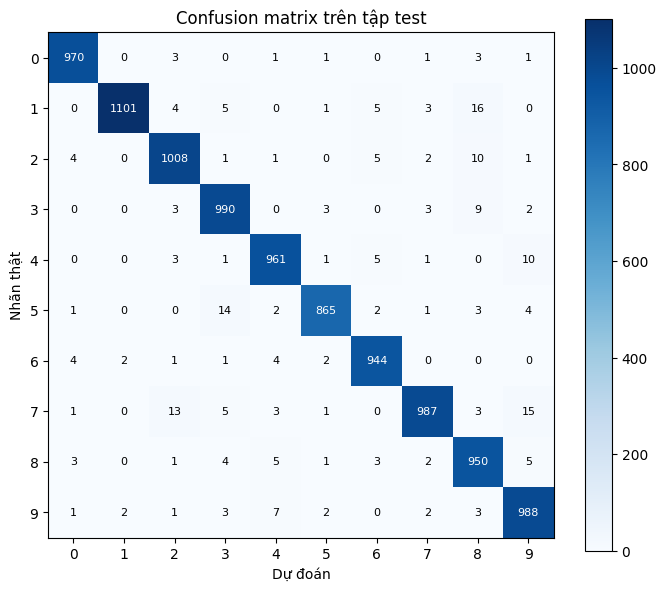

Top-3 cặp model hay nhầm nhất (thật → đoán: số lần):
  1 → 8: 16 lần
  7 → 9: 15 lần
  5 → 3: 14 lần


In [ ]:
model.eval()
cm = torch.zeros(10, 10, dtype=torch.long)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        for t, p in zip(labels, preds):
            cm[t.item(), p.item()] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm.numpy(), cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Dự đoán'); ax.set_ylabel('Nhãn thật'); ax.set_title('Confusion matrix trên tập test')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j].item(), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Xem top-3 cặp nhầm nhiều nhất
off_diag = cm.clone()
off_diag.fill_diagonal_(0)
flat_idx = torch.topk(off_diag.flatten(), 3).indices
print('Top-3 cặp model hay nhầm nhất (thật → đoán: số lần):')
for idx in flat_idx:
    i, j = idx.item() // 10, idx.item() % 10
    print(f'  {i} → {j}: {cm[i, j].item()} lần')

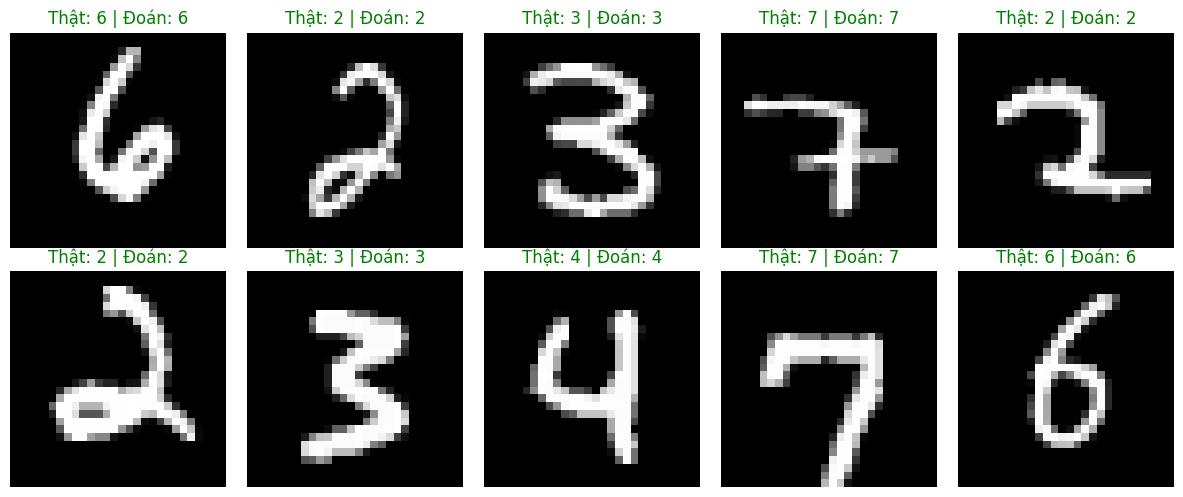

In [ ]:
model.eval()
indices = np.random.choice(len(test_dataset), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
with torch.no_grad():
    for ax, idx in zip(axes.flat, indices):
        img, label = test_dataset[idx]
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()
        # un-normalize lại để hiển thị cho dễ nhìn
        ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
        color = 'green' if pred == label else 'red'
        ax.set_title(f'Thật: {label} | Đoán: {pred}', color=color)
        ax.axis('off')
plt.tight_layout()
plt.show()

## Resources
Bài 1: Sâu hơn có tốt hơn không?
Thêm 1 lớp ẩn nữa (784 → 256 → 128 → 10). So sánh test accuracy với model 1 lớp ẩn ban đầu.

Gợi ý: chỉ cần thêm self.fc_mid = nn.Linear(256, 128) và sửa fc1 thành Linear(784, 256).
Báo cáo: số tham số tăng bao nhiêu, accuracy có tăng tương xứng không?
Bài 2: Ảnh hưởng của learning rate
Train lại model gốc với 3 giá trị lr ∈ {1e-2, 1e-3, 1e-4}, vẽ 3 đường loss trên cùng đồ thị.

Gợi ý: viết một hàm train(lr) trả về loss_history, gọi 3 lần.
Quan sát: lr nào hội tụ nhanh, lr nào dao động, lr nào quá chậm?
Bài 3: Thêm Dropout
Chèn nn.Dropout(p=0.3) giữa hai lớp Linear. Train 15 epoch và so sánh khoảng cách train_acc - test_acc trước và sau khi thêm Dropout.

Gợi ý: Dropout chỉ hoạt động khi model.train(); ở model.eval() nó tự tắt.
Mục tiêu: chứng minh Dropout giúp giảm overfitting (gap nhỏ lại).
Bài 4: Phân tích sai số theo lớp
Từ confusion matrix, tính accuracy theo từng lớp (per-class accuracy). Lớp nào model làm tệ nhất?

Gợi ý: cm[i, i] / cm[i].sum() cho lớp i.
Bonus: in ra 5 ảnh trong lớp tệ nhất bị đoán sai, xem có giống chữ nào khác không.
Bài 5: Vẽ trọng số của fc1
Lấy model.fc1.weight (shape [128, 784]), reshape mỗi hàng thành ảnh 28×28 và vẽ 16 hàng đầu tiên thành lưới 4×4.

Gợi ý: weights = model.fc1.weight.detach().cpu().view(128, 28, 28).
Quan sát: các "feature" mà neuron đầu tiên học được trông như thế nào?

### Bài 1: Sâu hơn có tốt hơn không?

In [ ]:
class ANN_Deeper(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc_mid = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc_mid(x))
        x = self.fc2(x)
        return x

model_deeper = ANN_Deeper().to(device)
print(model_deeper)

# Đếm số tham số
n_params_deeper = sum(p.numel() for p in model_deeper.parameters() if p.requires_grad)
print(f'Tổng số tham số của model sâu hơn: {n_params_deeper:,}')
print(f'Số tham số của model ban đầu: {n_params:,}')
print(f'Số tham số tăng thêm: {n_params_deeper - n_params:,}')

ANN_Deeper(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (fc_mid): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Tổng số tham số của model sâu hơn: 235,146
Số tham số của model ban đầu: 101,770
Số tham số tăng thêm: 133,376


In [ ]:
criterion_deeper = nn.CrossEntropyLoss()
optimizer_deeper = optim.Adam(model_deeper.parameters(), lr=1e-3)

num_epochs_deeper = 10
train_loss_history_deeper, train_acc_history_deeper = [], []
test_loss_history_deeper,  test_acc_history_deeper  = [], []

print('\nHuấn luyện mô hình sâu hơn...')
for epoch in range(num_epochs_deeper):
    model_deeper.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_deeper.zero_grad()
        outputs = model_deeper(images)
        loss = criterion_deeper(outputs, labels)
        loss.backward()
        optimizer_deeper.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_deeper, test_loader) # Sử dụng hàm evaluate đã định nghĩa trước đó

    train_loss_history_deeper.append(train_loss)
    train_acc_history_deeper.append(train_acc)
    test_loss_history_deeper.append(test_loss)
    test_acc_history_deeper.append(test_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs_deeper}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%   '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')


Huấn luyện mô hình sâu hơn...
Epoch  1/10  train_loss=0.2335  train_acc=93.00%   test_loss=0.1105  test_acc=96.37%
Epoch  2/10  train_loss=0.0948  train_acc=97.07%   test_loss=0.0858  test_acc=97.32%
Epoch  3/10  train_loss=0.0656  train_acc=97.92%   test_loss=0.0854  test_acc=97.39%
Epoch  4/10  train_loss=0.0520  train_acc=98.37%   test_loss=0.0682  test_acc=97.96%
Epoch  5/10  train_loss=0.0398  train_acc=98.66%   test_loss=0.0858  test_acc=97.42%
Epoch  6/10  train_loss=0.0333  train_acc=98.90%   test_loss=0.0801  test_acc=97.68%
Epoch  7/10  train_loss=0.0294  train_acc=99.03%   test_loss=0.0859  test_acc=97.78%
Epoch  8/10  train_loss=0.0257  train_acc=99.16%   test_loss=0.0734  test_acc=97.98%
Epoch  9/10  train_loss=0.0210  train_acc=99.28%   test_loss=0.0908  test_acc=97.61%
Epoch 10/10  train_loss=0.0201  train_acc=99.36%   test_loss=0.0927  test_acc=97.75%


### So sánh hiệu suất của hai mô hình

Test Accuracy của model ban đầu: 97.64%
Test Accuracy của model sâu hơn: 97.75%


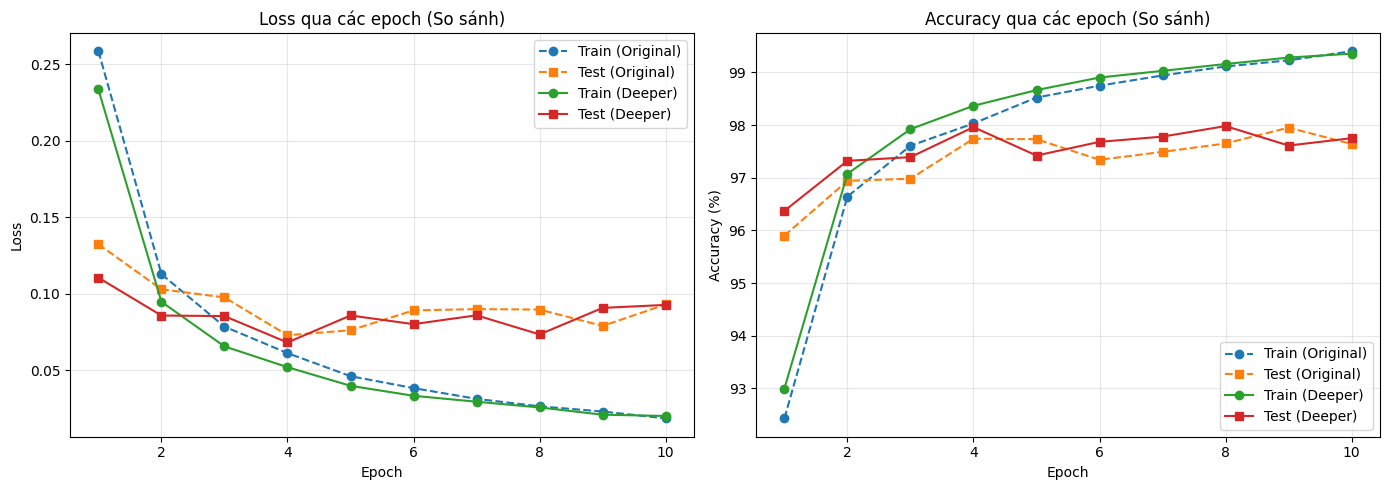

In [ ]:
print(f'Test Accuracy của model ban đầu: {test_acc_history[-1]*100:.2f}%')
print(f'Test Accuracy của model sâu hơn: {test_acc_history_deeper[-1]*100:.2f}%')

epochs_deeper = range(1, num_epochs_deeper + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Comparison
axes[0].plot(epochs, train_loss_history, 'o--', label='Train (Original)')
axes[0].plot(epochs, test_loss_history,  's--', label='Test (Original)')
axes[0].plot(epochs_deeper, train_loss_history_deeper, 'o-', label='Train (Deeper)')
axes[0].plot(epochs_deeper, test_loss_history_deeper,  's-', label='Test (Deeper)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss qua các epoch (So sánh)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy Comparison
axes[1].plot(epochs, [a*100 for a in train_acc_history], 'o--', label='Train (Original)')
axes[1].plot(epochs, [a*100 for a in test_acc_history],  's--', label='Test (Original)')
axes[1].plot(epochs_deeper, [a*100 for a in train_acc_history_deeper], 'o-', label='Train (Deeper)')
axes[1].plot(epochs_deeper, [a*100 for a in test_acc_history_deeper],  's-', label='Test (Deeper)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy qua các epoch (So sánh)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Bài 2: Ảnh hưởng của learning rate

In [ ]:
def train_with_lr(lr, num_epochs=10):
    print(f'\nHuấn luyện model với learning rate = {lr}')
    # Reset model và optimizer để đảm bảo mỗi lần train là độc lập
    local_model = ANN().to(device)
    local_optimizer = optim.Adam(local_model.parameters(), lr=lr)
    local_criterion = nn.CrossEntropyLoss()

    local_train_loss_history, local_train_acc_history = [], []
    local_test_loss_history,  local_test_acc_history  = [], []

    for epoch in range(num_epochs):
        local_model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            local_optimizer.zero_grad()
            outputs = local_model(images)
            loss = local_criterion(outputs, labels)
            loss.backward()
            local_optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(local_model, test_loader)

        local_train_loss_history.append(train_loss)
        local_train_acc_history.append(train_acc)
        local_test_loss_history.append(test_loss)
        local_test_acc_history.append(test_acc)

        print(f'Epoch {epoch+1:2d}/{num_epochs}  '
              f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%   '
              f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

    return local_train_loss_history, local_test_loss_history, local_model


Huấn luyện model với learning rate = 0.01
Epoch  1/10  train_loss=0.2884  train_acc=91.56%   test_loss=0.2226  test_acc=94.05%
Epoch  2/10  train_loss=0.1980  train_acc=94.55%   test_loss=0.1960  test_acc=94.66%
Epoch  3/10  train_loss=0.1929  train_acc=95.00%   test_loss=0.2235  test_acc=94.56%
Epoch  4/10  train_loss=0.1759  train_acc=95.41%   test_loss=0.2039  test_acc=94.92%
Epoch  5/10  train_loss=0.1644  train_acc=95.76%   test_loss=0.2424  test_acc=94.82%
Epoch  6/10  train_loss=0.1687  train_acc=95.72%   test_loss=0.2546  test_acc=94.43%
Epoch  7/10  train_loss=0.1674  train_acc=95.81%   test_loss=0.2197  test_acc=95.42%
Epoch  8/10  train_loss=0.1580  train_acc=96.17%   test_loss=0.2264  test_acc=94.98%
Epoch  9/10  train_loss=0.1540  train_acc=96.18%   test_loss=0.2878  test_acc=95.15%
Epoch 10/10  train_loss=0.1546  train_acc=96.28%   test_loss=0.2807  test_acc=94.95%

Huấn luyện model với learning rate = 0.001
Epoch  1/10  train_loss=0.2574  train_acc=92.51%   test_loss=0.

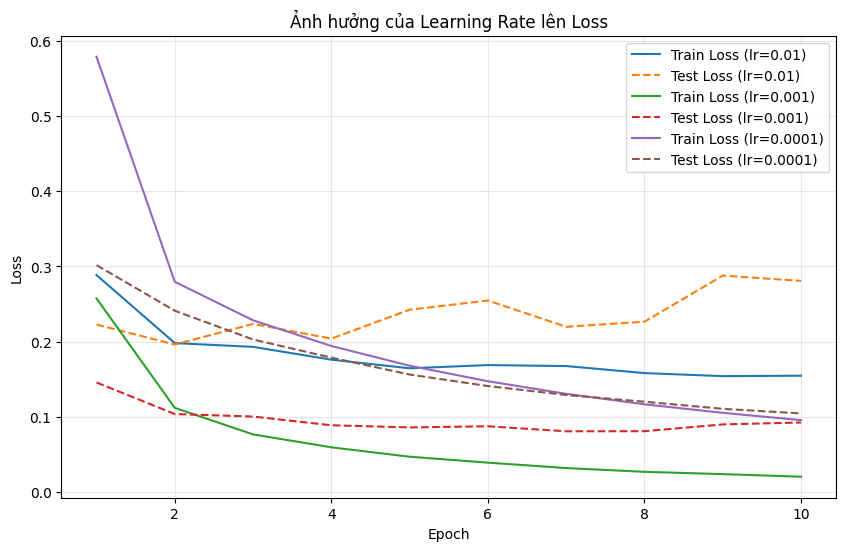

In [ ]:
learning_rates = [1e-2, 1e-3, 1e-4]
results = {}

for lr in learning_rates:
    train_loss, test_loss, _ = train_with_lr(lr)
    results[lr] = {'train_loss': train_loss, 'test_loss': test_loss}

plt.figure(figsize=(10, 6))
epochs_plot = range(1, num_epochs + 1) # Sử dụng num_epochs từ model gốc

for lr, history in results.items():
    plt.plot(epochs_plot, history['train_loss'], label=f'Train Loss (lr={lr})')
    plt.plot(epochs_plot, history['test_loss'], '--', label=f'Test Loss (lr={lr})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ảnh hưởng của Learning Rate lên Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Bài 3: Thêm Dropout

In [ ]:
class ANN_Dropout(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_dropout = ANN_Dropout(dropout_p=0.3).to(device)
print(model_dropout)

n_params_dropout = sum(p.numel() for p in model_dropout.parameters() if p.requires_grad)
print(f'Tổng số tham số của model có Dropout: {n_params_dropout:,}')

ANN_Dropout(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Tổng số tham số của model có Dropout: 101,770


In [ ]:
criterion_dropout = nn.CrossEntropyLoss()
optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=1e-3)

num_epochs_dropout = 15 # Train 15 epochs như yêu cầu
train_loss_history_dropout, train_acc_history_dropout = [], []
test_loss_history_dropout,  test_acc_history_dropout  = [], []

print('\nHuấn luyện mô hình với Dropout...')
for epoch in range(num_epochs_dropout):
    model_dropout.train() # Dropout hoạt động ở chế độ train
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_dropout.zero_grad()
        outputs = model_dropout(images)
        loss = criterion_dropout(outputs, labels)
        loss.backward()
        optimizer_dropout.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_dropout, test_loader) # evaluate() tự động gọi model.eval()

    train_loss_history_dropout.append(train_loss)
    train_acc_history_dropout.append(train_acc)
    test_loss_history_dropout.append(test_loss)
    test_acc_history_dropout.append(test_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs_dropout}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%   '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')


Huấn luyện mô hình với Dropout...
Epoch  1/15  train_loss=0.3177  train_acc=90.59%   test_loss=0.1396  test_acc=95.84%
Epoch  2/15  train_loss=0.1637  train_acc=95.22%   test_loss=0.1052  test_acc=96.81%
Epoch  3/15  train_loss=0.1302  train_acc=95.99%   test_loss=0.0943  test_acc=97.29%
Epoch  4/15  train_loss=0.1113  train_acc=96.61%   test_loss=0.0826  test_acc=97.55%
Epoch  5/15  train_loss=0.1057  train_acc=96.68%   test_loss=0.0839  test_acc=97.47%
Epoch  6/15  train_loss=0.0950  train_acc=97.05%   test_loss=0.0829  test_acc=97.56%
Epoch  7/15  train_loss=0.0875  train_acc=97.26%   test_loss=0.0805  test_acc=97.64%
Epoch  8/15  train_loss=0.0790  train_acc=97.42%   test_loss=0.0851  test_acc=97.51%
Epoch  9/15  train_loss=0.0765  train_acc=97.56%   test_loss=0.0803  test_acc=97.75%
Epoch 10/15  train_loss=0.0732  train_acc=97.67%   test_loss=0.0839  test_acc=97.84%
Epoch 11/15  train_loss=0.0700  train_acc=97.66%   test_loss=0.0765  test_acc=97.93%
Epoch 12/15  train_loss=0.0643

### So sánh khoảng cách train_acc - test_acc

Khoảng cách train_acc - test_acc (model gốc): 1.76%
Khoảng cách train_acc - test_acc (model có Dropout): 0.02%


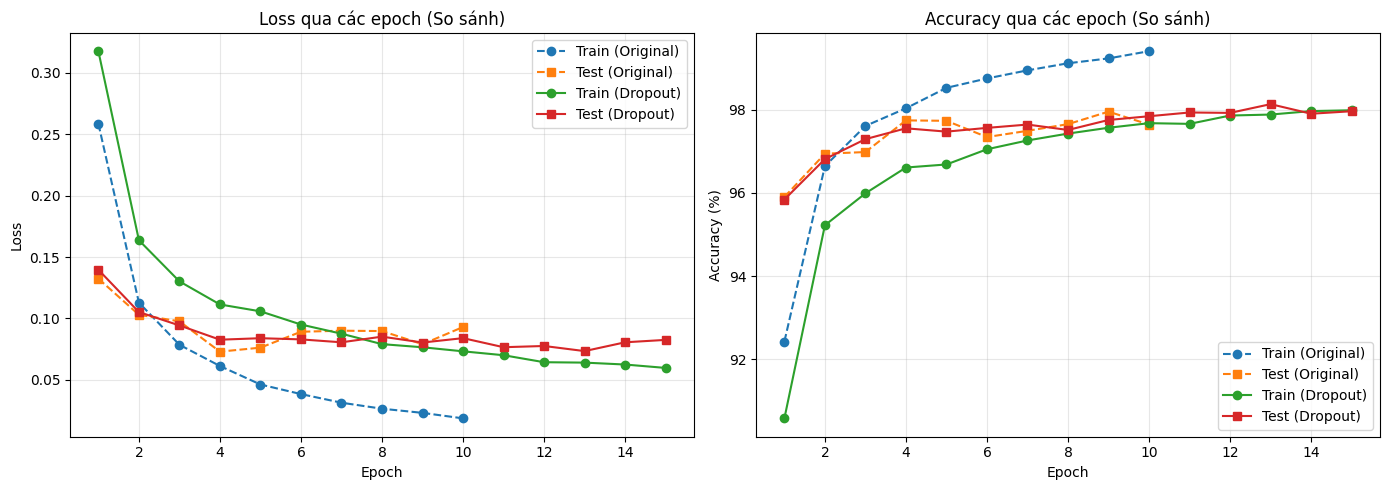

In [ ]:
gap_original = (train_acc_history[-1] - test_acc_history[-1]) * 100
gap_dropout  = (train_acc_history_dropout[-1] - test_acc_history_dropout[-1]) * 100

print(f'Khoảng cách train_acc - test_acc (model gốc): {gap_original:.2f}%')
print(f'Khoảng cách train_acc - test_acc (model có Dropout): {gap_dropout:.2f}%')

epochs_dropout = range(1, num_epochs_dropout + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Comparison
axes[0].plot(epochs, train_loss_history, 'o--', label='Train (Original)')
axes[0].plot(epochs, test_loss_history,  's--', label='Test (Original)')
axes[0].plot(epochs_dropout, train_loss_history_dropout, 'o-', label='Train (Dropout)')
axes[0].plot(epochs_dropout, test_loss_history_dropout,  's-', label='Test (Dropout)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss qua các epoch (So sánh)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy Comparison
axes[1].plot(epochs, [a*100 for a in train_acc_history], 'o--', label='Train (Original)')
axes[1].plot(epochs, [a*100 for a in test_acc_history],  's--', label='Test (Original)')
axes[1].plot(epochs_dropout, [a*100 for a in train_acc_history_dropout], 'o-', label='Train (Dropout)')
axes[1].plot(epochs_dropout, [a*100 for a in test_acc_history_dropout],  's-', label='Test (Dropout)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy qua các epoch (So sánh)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Bài 4: Phân tích sai số theo lớp

In [ ]:
# Tính toán per-class accuracy từ confusion matrix (cm đã được tạo từ model gốc)
class_accuracies = []
for i in range(10):
    correct_predictions = cm[i, i].item()
    total_true = cm[i].sum().item()
    if total_true > 0:
        accuracy = correct_predictions / total_true
        class_accuracies.append((i, accuracy))
    else:
        class_accuracies.append((i, 0.0)) # Nếu không có mẫu nào của lớp này trong tập test

print('Accuracy theo từng lớp:')
for class_idx, acc in class_accuracies:
    print(f'  Lớp {class_idx}: {acc*100:.2f}%')

# Tìm lớp có accuracy tệ nhất
worst_class_idx, worst_accuracy = min(class_accuracies, key=lambda item: item[1])
print(f'Lớp model làm tệ nhất là: {worst_class_idx} với accuracy {worst_accuracy*100:.2f}%')

Accuracy theo từng lớp:
  Lớp 0: 98.98%
  Lớp 1: 97.00%
  Lớp 2: 97.67%
  Lớp 3: 98.02%
  Lớp 4: 97.86%
  Lớp 5: 96.97%
  Lớp 6: 98.54%
  Lớp 7: 96.01%
  Lớp 8: 97.54%
  Lớp 9: 97.92%
Lớp model làm tệ nhất là: 7 với accuracy 96.01%


### Bonus: In ra 5 ảnh trong lớp tệ nhất bị đoán sai

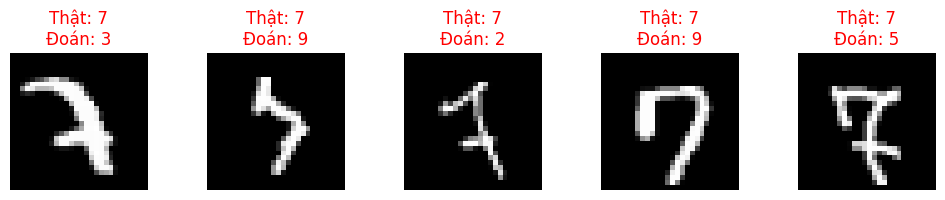

In [ ]:
model.eval()
wrong_predictions_worst_class = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):
            if labels[i].item() == worst_class_idx and preds[i].item() != worst_class_idx:
                wrong_predictions_worst_class.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))

# Lấy tối đa 5 ảnh bị đoán sai
num_display = min(5, len(wrong_predictions_worst_class))
if num_display > 0:
    fig, axes = plt.subplots(1, num_display, figsize=(2 * num_display, 2))
    if num_display == 1: # Handle case of single image for plotting
        axes = [axes]
    for i, (img, true_label, pred_label) in enumerate(wrong_predictions_worst_class[:num_display]):
        axes[i].imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
        axes[i].set_title(f'Thật: {true_label.item()}\nĐoán: {pred_label.item()}', color='red')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f'Không có ảnh nào của lớp {worst_class_idx} bị đoán sai trong 5 ảnh đầu.')

### Bài 5: Vẽ trọng số của fc1

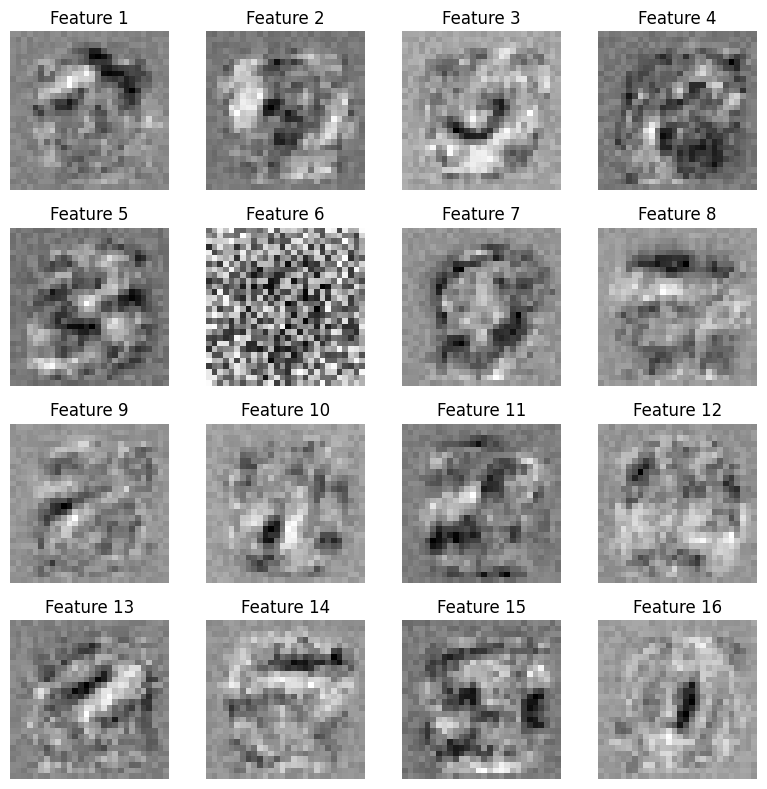

In [ ]:
# Lấy trọng số từ lớp fc1
# weights có shape [out_features, in_features] = [128, 784]
weights = model.fc1.weight.detach().cpu().view(128, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    if i < len(weights):
        ax.imshow(weights[i].numpy(), cmap='gray')
        ax.set_title(f'Feature {i+1}')
        ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots if less than 16 weights

plt.tight_layout()
plt.show()